In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

In [2]:
df = pd.read_csv(
    "US_Accidents_March23.csv",

    # Only important columns
    usecols=[
        'Severity',
        'Start_Time',
        'Weather_Condition',
        'Temperature(F)',
        'Visibility(mi)',
        'Humidity(%)',
        'Wind_Speed(mph)',
        'City',
        'State',
        'Start_Lat',
        'Start_Lng'
    ],

    # Load only first 100000 rows
    nrows=100000
)

print("Dataset Loaded Successfully ✅")
print(df.head())

Dataset Loaded Successfully ✅
   Severity           Start_Time  Start_Lat  Start_Lng          City State  \
0         3  2016-02-08 05:46:00  39.865147 -84.058723        Dayton    OH   
1         2  2016-02-08 06:07:59  39.928059 -82.831184  Reynoldsburg    OH   
2         2  2016-02-08 06:49:27  39.063148 -84.032608  Williamsburg    OH   
3         3  2016-02-08 07:23:34  39.747753 -84.205582        Dayton    OH   
4         2  2016-02-08 07:39:07  39.627781 -84.188354        Dayton    OH   

   Temperature(F)  Humidity(%)  Visibility(mi)  Wind_Speed(mph)  \
0            36.9         91.0            10.0              NaN   
1            37.9        100.0            10.0              NaN   
2            36.0        100.0            10.0              3.5   
3            35.1         96.0             9.0              4.6   
4            36.0         89.0             6.0              3.5   

  Weather_Condition  
0        Light Rain  
1        Light Rain  
2          Overcast  
3     Most

In [3]:
df.dropna(inplace=True)

In [4]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.day_name()

C:\Users\user\AppData\Local\Temp\ipykernel_9916\4054313713.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


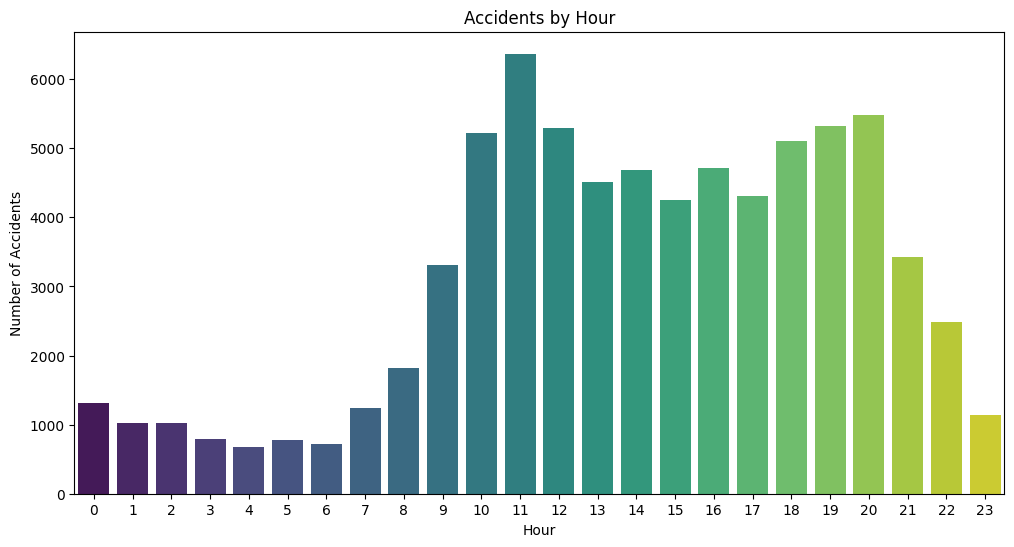

In [16]:
plt.figure(figsize=(12,6))

sns.countplot(
    x=df['Hour'],
    palette='viridis'
)

plt.title("Accidents by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.savefig("images/accidents_by_hour")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_9916\4271185356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


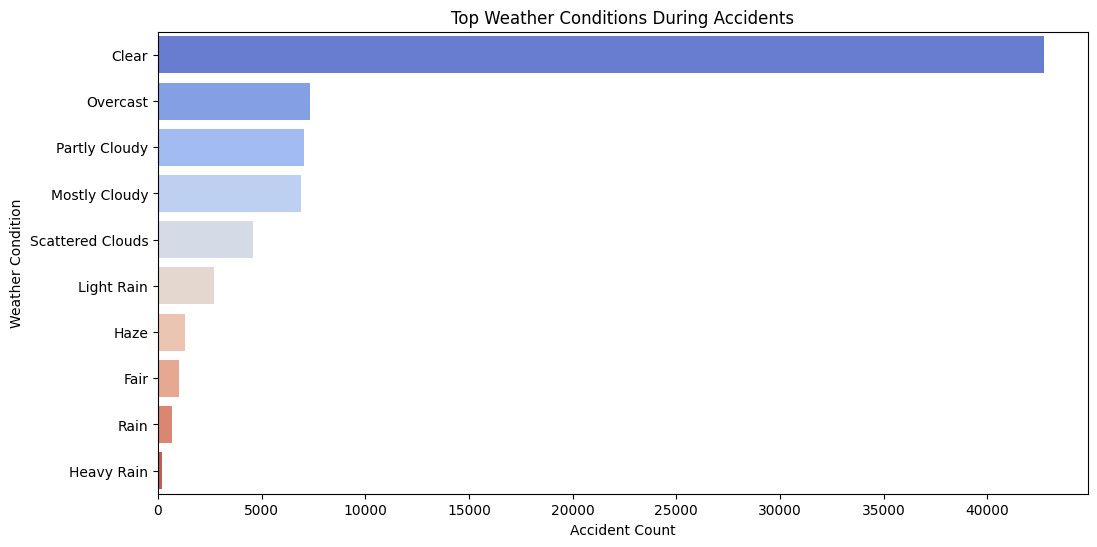

In [17]:
top_weather = df['Weather_Condition'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_weather.values,
    y=top_weather.index,
    palette='coolwarm'
)

plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Accident Count")
plt.ylabel("Weather Condition")
plt.savefig("images/accidents_by_weather")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_9916\3803063070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


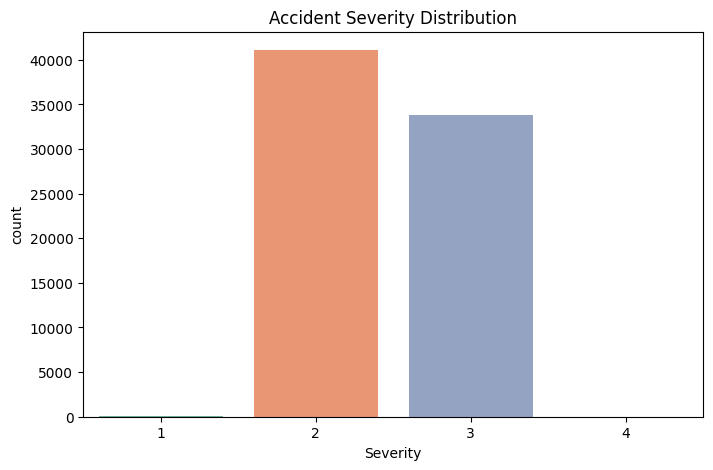

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Severity',
    data=df,
    palette='Set2'
)

plt.title("Accident Severity Distribution")
plt.savefig("images/severity_distribution")
plt.show()

In [8]:
sample_df = df.sample(5000)

m = folium.Map(
    location=[39.5, -98.35],
    zoom_start=4
)

heat_data = [
    [row['Start_Lat'], row['Start_Lng']]
    for index, row in sample_df.iterrows()
]

HeatMap(heat_data).add_to(m)

m.save("hotspot_map.html")

print("\nHotspot map saved as hotspot_map.html ✅")


Hotspot map saved as hotspot_map.html ✅
